In [1]:
!pip install requests pandas

In [2]:
import requests
import pandas as pd

# FRED API Key
api_key = "YOUR_FRED_API_KEY"

# series ID for 30 year mortgage
series_id = "MORTGAGE30US"

url = f"https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": series_id,
    "api_key": api_key,
    "file_type": "json"
}

response = requests.get(url, params=params)
data = response.json()

# convert to a pandas DataFrame
mortgage_df = pd.DataFrame(data["observations"])

In [3]:
mortgage_df.head()

,realtime_start,realtime_end,date,value
0,2026-09-17,2026-09-17,1971-04-02,7.33
1,2026-09-17,2026-09-17,1971-04-09,7.31
2,2026-09-17,2026-09-17,1971-04-16,7.31
3,2026-09-17,2026-09-17,1971-04-23,7.31
4,2026-09-17,2026-09-17,1971-04-30,7.29


In [4]:
# unemployment rate
series_id = "UNRATE"
params["series_id"] = series_id
response = requests.get(url, params=params)
data = response.json()
unemployment_df = pd.DataFrame(data["observations"])
unemployment_df.head()

,realtime_start,realtime_end,date,value
0,2026-09-04,2026-09-04,1948-01-01,3.4
1,2026-09-04,2026-09-04,1948-02-01,3.8
2,2026-09-04,2026-09-04,1948-03-01,4.0
3,2026-09-04,2026-09-04,1948-04-01,3.9
4,2026-09-04,2026-09-04,1948-05-01,3.5


In [5]:
# inflation (CPI)
series_id = "CPIAUCSL"
params["series_id"] = series_id
response = requests.get(url, params=params)
data = response.json()
inflation_df = pd.DataFrame(data["observations"])
inflation_df.head()

,realtime_start,realtime_end,date,value
0,2026-09-11,2026-09-11,1947-01-01,21.48
1,2026-09-11,2026-09-11,1947-02-01,21.62
2,2026-09-11,2026-09-11,1947-03-01,22.0
3,2026-09-11,2026-09-11,1947-04-01,22.0
4,2026-09-11,2026-09-11,1947-05-01,21.95


In [6]:
# Clean mortgage rate data
mortgage_df = mortgage_df[["date", "value"]]
mortgage_df["date"] = pd.to_datetime(mortgage_df["date"])
mortgage_df["value"] = pd.to_numeric(mortgage_df["value"], errors="coerce")
mortgage_df = mortgage_df.rename(columns={"value": "mortgage_rate"})

# Clean unemployment data
unemployment_df = unemployment_df[["date", "value"]]
unemployment_df["date"] = pd.to_datetime(unemployment_df["date"])
unemployment_df["value"] = pd.to_numeric(unemployment_df["value"], errors="coerce")
unemployment_df = unemployment_df.rename(columns={"value": "unemployment_rate"})

# Clean inflation data
inflation_df = inflation_df[["date", "value"]]
inflation_df["date"] = pd.to_datetime(inflation_df["date"])
inflation_df["value"] = pd.to_numeric(inflation_df["value"], errors="coerce")
inflation_df = inflation_df.rename(columns={"value": "cpi"})

mortgage_df.head()

,date,mortgage_rate
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [10]:
unemployment_df.head()

,date,unemployment_rate
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [12]:
inflation_df.head()

,date,cpi
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [22]:
zillow_df = pd.read_csv("Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
zillow_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31,2026-08-31
0,102001,0,United States,country,NaN,123577.759599,123795.172495,124064.796497,124643.087057,125308.630160,...,365789.637187,366588.387076,367350.446884,368071.714278,368567.172902,368647.332960,368385.291351,368141.647036,368249.996720,368696.684749
1,394913,1,"New York, NY",msa,NY,220013.123643,220948.055283,221891.646074,223803.726142,225783.751268,...,708946.175873,712394.824490,715484.029453,719086.862434,722906.455133,725334.945516,726872.561905,728366.597785,731367.802254,735075.472720
2,753899,2,"Los Angeles, CA",msa,CA,221912.269808,222738.065012,223838.016347,226026.550004,228420.119716,...,948164.084432,952130.048187,954663.897072,955897.637375,955563.237098,953938.720216,952480.487123,950999.855511,951215.347307,952601.248169
3,394463,3,"Chicago, IL",msa,IL,156387.253909,156532.022949,156807.738135,157493.649000,158318.717268,...,344798.361117,346563.956713,348215.063279,349995.182297,351427.852617,352446.017678,353069.521399,353938.432884,355375.931563,357264.935404
4,394514,4,"Dallas, TX",msa,TX,129720.857830,129778.635953,129845.057821,130017.548434,130244.972584,...,367550.988498,367329.712410,366889.093929,366304.482462,365232.417762,363899.148350,362320.808555,361073.950589,360453.497967,360436.817305


In [24]:
target_metros = [
    "New York, NY", "Los Angeles, CA", "Chicago, IL", "Dallas, TX",
    "Houston, TX", "Washington, DC", "Miami, FL", "Philadelphia, PA",
    "Atlanta, GA", "Phoenix, AZ", "Boston, MA", "San Francisco, CA",
    "Riverside, CA", "Detroit, MI", "Seattle, WA"
]

filtered_zillow = zillow_df[zillow_df["RegionName"].isin(target_metros)]
filtered_zillow[["RegionName"]]

,RegionName
1,"New York, NY"
2,"Los Angeles, CA"
3,"Chicago, IL"
4,"Dallas, TX"
5,"Houston, TX"
6,"Washington, DC"
7,"Philadelphia, PA"
8,"Miami, FL"
9,"Atlanta, GA"
10,"Boston, MA"


In [28]:
# Keep only RegionName and the date columns
zillow_trimmed = filtered_zillow.drop(columns=["RegionID", "SizeRank", "RegionType", "StateName"])

# Reshape from wide to long format
zillow_long = zillow_trimmed.melt(
    id_vars=["RegionName"],
    var_name="date",
    value_name="home_value"
)

# Convert date column to actual datetime
zillow_long["date"] = pd.to_datetime(zillow_long["date"])

zillow_long.head()

,RegionName,date,home_value
0,"New York, NY",2000-01-31,220013.123643
1,"Los Angeles, CA",2000-01-31,221912.269808
2,"Chicago, IL",2000-01-31,156387.253909
3,"Dallas, TX",2000-01-31,129720.857830
4,"Houston, TX",2000-01-31,125726.049793


In [30]:
# Merge FRED datasets together first (all national-level, by date)
fred_merged = mortgage_df.merge(unemployment_df, on="date", how="inner")
fred_merged = fred_merged.merge(inflation_df, on="date", how="inner")

fred_merged.head()

,date,mortgage_rate,unemployment_rate,cpi
0,1971-10-01,7.67,5.8,40.9
1,1972-09-01,7.42,5.5,42.1
2,1972-12-01,7.45,5.2,42.5
3,1973-06-01,7.70,4.9,44.2
4,1974-02-01,8.48,5.2,47.3


In [32]:
# Convert mortgage rate from weekly to monthly (average per month)
mortgage_df["month"] = mortgage_df["date"].dt.to_period("M")
mortgage_monthly = mortgage_df.groupby("month")["mortgage_rate"].mean().reset_index()
mortgage_monthly["date"] = mortgage_monthly["month"].dt.to_timestamp()
mortgage_monthly = mortgage_monthly[["date", "mortgage_rate"]]

mortgage_monthly.head()

,date,mortgage_rate
0,1971-04-01,7.3100
1,1971-05-01,7.4250
2,1971-06-01,7.5300
3,1971-07-01,7.6040
4,1971-08-01,7.6975


In [34]:
# Merge FRED datasets together (all now monthly)
fred_merged = mortgage_monthly.merge(unemployment_df, on="date", how="inner")
fred_merged = fred_merged.merge(inflation_df, on="date", how="inner")

fred_merged.head()

,date,mortgage_rate,unemployment_rate,cpi
0,1971-04-01,7.3100,5.9,40.1
1,1971-05-01,7.4250,5.9,40.3
2,1971-06-01,7.5300,5.9,40.5
3,1971-07-01,7.6040,6.0,40.6
4,1971-08-01,7.6975,6.1,40.7


In [36]:
# Merge FRED data into Zillow data (by date)
final_df = zillow_long.merge(fred_merged, on="date", how="inner")

final_df.head()

,RegionName,date,home_value,mortgage_rate,unemployment_rate,cpi


In [38]:
# Standardize both date columns to year-month only
zillow_long["year_month"] = zillow_long["date"].dt.to_period("M")
fred_merged["year_month"] = fred_merged["date"].dt.to_period("M")

# Merge on year_month instead of exact date
final_df = zillow_long.merge(fred_merged, on="year_month", how="inner")

final_df.head()

,RegionName,date_x,home_value,year_month,date_y,mortgage_rate,unemployment_rate,cpi
0,"New York, NY",2000-01-31,220013.123643,2000-01,2000-01-01,8.21,4.0,169.3
1,"Los Angeles, CA",2000-01-31,221912.269808,2000-01,2000-01-01,8.21,4.0,169.3
2,"Chicago, IL",2000-01-31,156387.253909,2000-01,2000-01-01,8.21,4.0,169.3
3,"Dallas, TX",2000-01-31,129720.857830,2000-01,2000-01-01,8.21,4.0,169.3
4,"Houston, TX",2000-01-31,125726.049793,2000-01,2000-01-01,8.21,4.0,169.3


In [40]:
# Clean up duplicate date columns
final_df = final_df.drop(columns=["date_x", "date_y"])
final_df = final_df.rename(columns={"year_month": "date"})

final_df.head()

,RegionName,home_value,date,mortgage_rate,unemployment_rate,cpi
0,"New York, NY",220013.123643,2000-01,8.21,4.0,169.3
1,"Los Angeles, CA",221912.269808,2000-01,8.21,4.0,169.3
2,"Chicago, IL",156387.253909,2000-01,8.21,4.0,169.3
3,"Dallas, TX",129720.857830,2000-01,8.21,4.0,169.3
4,"Houston, TX",125726.049793,2000-01,8.21,4.0,169.3


In [42]:
# Sort by metro and date - critical for time-series calculations
final_df = final_df.sort_values(["RegionName", "date"]).reset_index(drop=True)
final_df.head()

,RegionName,home_value,date,mortgage_rate,unemployment_rate,cpi
0,"Atlanta, GA",149854.045713,2000-01,8.2100,4.0,169.3
1,"Atlanta, GA",150199.433601,2000-02,8.3250,4.1,170.0
2,"Atlanta, GA",150606.364469,2000-03,8.2400,4.0,171.0
3,"Atlanta, GA",151471.861496,2000-04,8.1525,3.8,170.9
4,"Atlanta, GA",152438.773513,2000-05,8.5150,4.0,171.2


In [44]:
# Create the target variable: did home prices go UP next month? (1 = yes, 0 = no)
final_df["next_month_value"] = final_df.groupby("RegionName")["home_value"].shift(-1)
final_df["price_direction"] = (final_df["next_month_value"] > final_df["home_value"]).astype(int)

final_df.head()

,RegionName,home_value,date,mortgage_rate,unemployment_rate,cpi,next_month_value,price_direction
0,"Atlanta, GA",149854.045713,2000-01,8.2100,4.0,169.3,150199.433601,1
1,"Atlanta, GA",150199.433601,2000-02,8.3250,4.1,170.0,150606.364469,1
2,"Atlanta, GA",150606.364469,2000-03,8.2400,4.0,171.0,151471.861496,1
3,"Atlanta, GA",151471.861496,2000-04,8.1525,3.8,170.9,152438.773513,1
4,"Atlanta, GA",152438.773513,2000-05,8.5150,4.0,171.2,153468.171902,1


In [46]:
# Create temporal features (per metro, so we don't mix data across cities)
final_df["mortgage_rate_lag1"] = final_df.groupby("RegionName")["mortgage_rate"].shift(1)
final_df["unemployment_rate_lag1"] = final_df.groupby("RegionName")["unemployment_rate"].shift(1)
final_df["cpi_lag1"] = final_df.groupby("RegionName")["cpi"].shift(1)

final_df["home_value_mom_change"] = final_df.groupby("RegionName")["home_value"].pct_change()
final_df["home_value_3mo_avg"] = final_df.groupby("RegionName")["home_value"].transform(lambda x: x.rolling(3).mean())

final_df.head()

/var/folders/0m/ywvp2cp56yjg9c784t9sh6tc0000gn/T/ipykernel_82760/550503610.py:6: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  final_df["home_value_mom_change"] = final_df.groupby("RegionName")["home_value"].pct_change()


,RegionName,home_value,date,mortgage_rate,unemployment_rate,cpi,next_month_value,price_direction,mortgage_rate_lag1,unemployment_rate_lag1,cpi_lag1,home_value_mom_change,home_value_3mo_avg
0,"Atlanta, GA",149854.045713,2000-01,8.2100,4.0,169.3,150199.433601,1,NaN,NaN,NaN,NaN,NaN
1,"Atlanta, GA",150199.433601,2000-02,8.3250,4.1,170.0,150606.364469,1,8.2100,4.0,169.3,0.002305,NaN
2,"Atlanta, GA",150606.364469,2000-03,8.2400,4.0,171.0,151471.861496,1,8.3250,4.1,170.0,0.002709,150219.947928
3,"Atlanta, GA",151471.861496,2000-04,8.1525,3.8,170.9,152438.773513,1,8.2400,4.0,171.0,0.005747,150759.219855
4,"Atlanta, GA",152438.773513,2000-05,8.5150,4.0,171.2,153468.171902,1,8.1525,3.8,170.9,0.006383,151505.666493


In [48]:
# Fix the pct_change warning by being explicit
final_df["home_value_mom_change"] = final_df.groupby("RegionName")["home_value"].pct_change(fill_method=None)

final_df.head()

,RegionName,home_value,date,mortgage_rate,unemployment_rate,cpi,next_month_value,price_direction,mortgage_rate_lag1,unemployment_rate_lag1,cpi_lag1,home_value_mom_change,home_value_3mo_avg
0,"Atlanta, GA",149854.045713,2000-01,8.2100,4.0,169.3,150199.433601,1,NaN,NaN,NaN,NaN,NaN
1,"Atlanta, GA",150199.433601,2000-02,8.3250,4.1,170.0,150606.364469,1,8.2100,4.0,169.3,0.002305,NaN
2,"Atlanta, GA",150606.364469,2000-03,8.2400,4.0,171.0,151471.861496,1,8.3250,4.1,170.0,0.002709,150219.947928
3,"Atlanta, GA",151471.861496,2000-04,8.1525,3.8,170.9,152438.773513,1,8.2400,4.0,171.0,0.005747,150759.219855
4,"Atlanta, GA",152438.773513,2000-05,8.5150,4.0,171.2,153468.171902,1,8.1525,3.8,170.9,0.006383,151505.666493


In [50]:
# Drop rows with missing values from our new features
model_df = final_df.dropna()

# Define features (X) and target (y)
features = [
    "mortgage_rate", "unemployment_rate", "cpi",
    "mortgage_rate_lag1", "unemployment_rate_lag1", "cpi_lag1",
    "home_value_mom_change", "home_value_3mo_avg"
]
X = model_df[features]
y = model_df["price_direction"]

# Sort by date to ensure proper time-series split
model_df = model_df.sort_values("date")

print(f"Total rows: {len(model_df)}")
print(f"Date range: {model_df['date'].min()} to {model_df['date'].max()}")

Total rows: 4716
Date range: 2000-03 to 2026-07


In [52]:
# Time-series split: train on earlier data, test on more recent data
cutoff_date = "2022-01"  # roughly last ~4.5 years held out for testing

train_df = model_df[model_df["date"] < cutoff_date]
test_df = model_df[model_df["date"] >= cutoff_date]

X_train = train_df[features]
y_train = train_df["price_direction"]
X_test = test_df[features]
y_test = test_df["price_direction"]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 3921
Testing rows: 795


In [54]:
# Baseline model: logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Train baseline logistic regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6238993710691824
F1 Score: 0.7683965917893106
ROC-AUC: 0.45192307692307687

Confusion Matrix:
[[  0 299]
 [  0 496]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       299
           1       0.62      1.00      0.77       496

    accuracy                           0.62       795
   macro avg       0.31      0.50      0.38       795
weighted avg       0.39      0.62      0.48       795



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [56]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

price_direction
1    2959
0     962
Name: count, dtype: int64
price_direction
1    0.754654
0    0.245346
Name: proportion, dtype: float64


In [58]:
from sklearn.preprocessing import StandardScaler

# Scale features so they're on comparable ranges
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain with class_weight='balanced' to address the imbalance
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.579874213836478
F1 Score: 0.5029761904761905
ROC-AUC: 0.9436360448807855

Confusion Matrix:
[[292   7]
 [327 169]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.98      0.64       299
           1       0.96      0.34      0.50       496

    accuracy                           0.58       795
   macro avg       0.72      0.66      0.57       795
weighted avg       0.78      0.58      0.55       795



In [60]:
# Try different probability thresholds to find a better balance
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65]

for t in thresholds:
    y_pred_adjusted = (y_pred_proba >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    print(f"Threshold: {t} | Accuracy: {acc:.3f} | F1: {f1:.3f}")

Threshold: 0.4 | Accuracy: 0.595 | F1: 0.531
Threshold: 0.45 | Accuracy: 0.586 | F1: 0.515
Threshold: 0.5 | Accuracy: 0.580 | F1: 0.503
Threshold: 0.55 | Accuracy: 0.571 | F1: 0.487
Threshold: 0.6 | Accuracy: 0.565 | F1: 0.474
Threshold: 0.65 | Accuracy: 0.557 | F1: 0.460


In [62]:
# Apply the best threshold found
best_threshold = 0.4
y_pred_tuned = (y_pred_proba >= best_threshold).astype(int)

print("Tuned Logistic Regression (threshold = 0.4)")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Logistic Regression (threshold = 0.4)
Accuracy: 0.5949685534591195
F1 Score: 0.5306122448979591

Confusion Matrix:
[[291   8]
 [314 182]]


In [64]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

# Predict on test set
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_pred_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy: 0.8830188679245283
F1 Score: 0.9097963142580019
ROC-AUC: 0.9417615168842377

Confusion Matrix:
[[233  66]
 [ 27 469]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.83       299
           1       0.88      0.95      0.91       496

    accuracy                           0.88       795
   macro avg       0.89      0.86      0.87       795
weighted avg       0.88      0.88      0.88       795



In [66]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
6,home_value_mom_change,0.458456
2,cpi,0.151952
5,cpi_lag1,0.143686
1,unemployment_rate,0.076022
4,unemployment_rate_lag1,0.051635
7,home_value_3mo_avg,0.041849
3,mortgage_rate_lag1,0.041387
0,mortgage_rate,0.035014


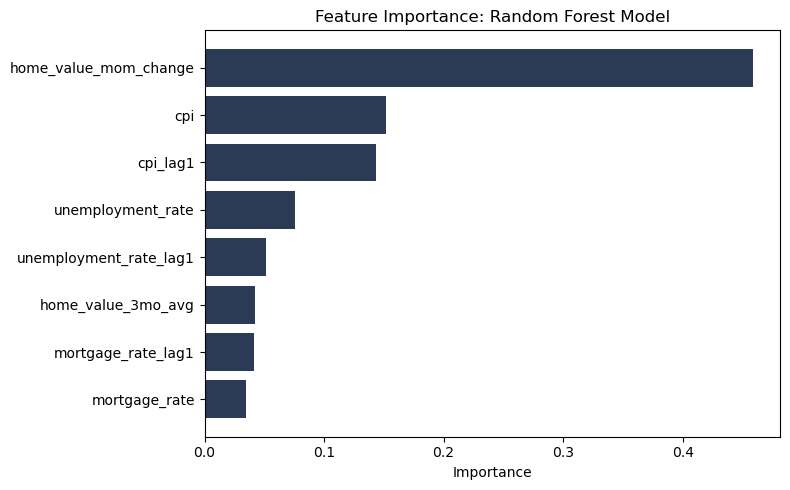

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color="#2b3a55")
plt.xlabel("Importance")
plt.title("Feature Importance: Random Forest Model")
plt.gca().invert_yaxis()  # highest importance at the top
plt.tight_layout()

# Save as an image file for your white paper
plt.savefig("feature_importance.png", dpi=300)
plt.show()

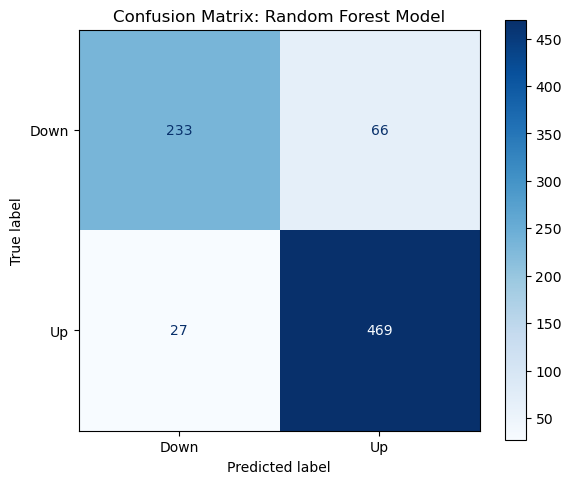

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=["Down", "Up"],
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix: Random Forest Model")
plt.tight_layout()

# Save for your white paper
plt.savefig("confusion_matrix_rf.png", dpi=300)
plt.show()

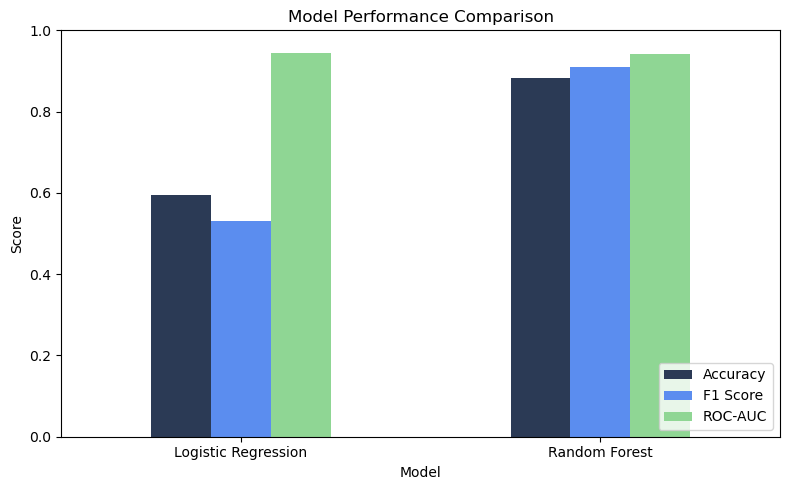

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.594969,0.530612,0.943636
1,Random Forest,0.883019,0.909796,0.941762


In [72]:
# Compare both models side by side
comparison_data = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_tuned), accuracy_score(y_test, rf_pred)],
    "F1 Score": [f1_score(y_test, y_pred_tuned), f1_score(y_test, rf_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_pred_proba), roc_auc_score(y_test, rf_pred_proba)]
}
comparison_df = pd.DataFrame(comparison_data)

# Plot
comparison_df.set_index("Model").plot(kind="bar", figsize=(8,5), color=["#2b3a55", "#5b8def", "#8fd694"])
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300)
plt.show()

comparison_df

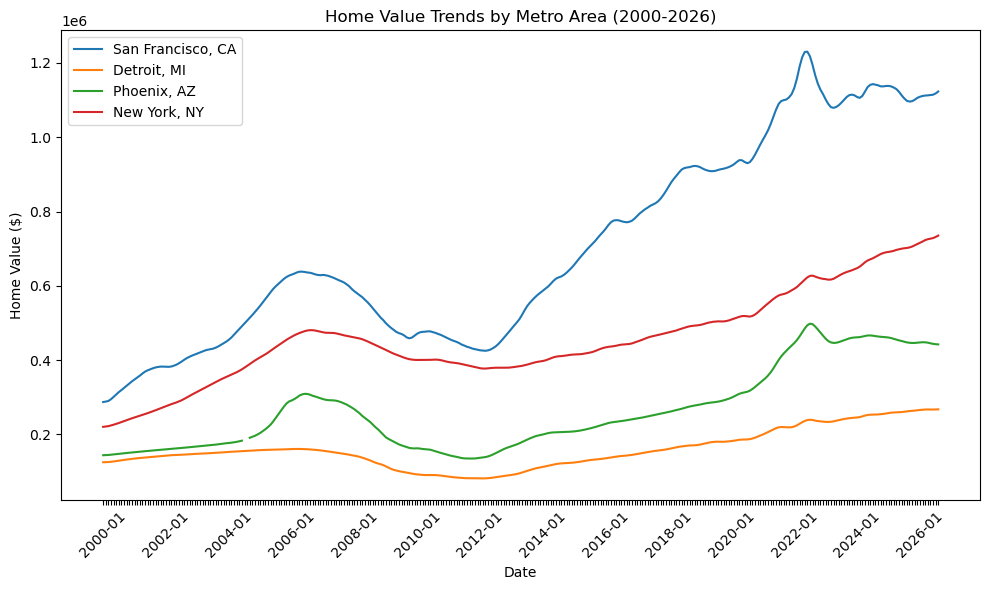

In [74]:
# Plot home value trends for a few contrasting metros
metros_to_plot = ["San Francisco, CA", "Detroit, MI", "Phoenix, AZ", "New York, NY"]

plt.figure(figsize=(10, 6))
for metro in metros_to_plot:
    metro_data = final_df[final_df["RegionName"] == metro]
    plt.plot(metro_data["date"].astype(str), metro_data["home_value"], label=metro)

plt.title("Home Value Trends by Metro Area (2000-2026)")
plt.xlabel("Date")
plt.ylabel("Home Value ($)")
plt.legend()
plt.xticks(rotation=45)

# Only show every 24th label to avoid crowding
ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 24 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.savefig("home_value_trends.png", dpi=300)
plt.show()

In [76]:
# Data dictionary for final_df
data_dictionary = pd.DataFrame({
    "Field": [
        "RegionName", "date", "home_value", "mortgage_rate", "unemployment_rate",
        "cpi", "next_month_value", "price_direction", "mortgage_rate_lag1",
        "unemployment_rate_lag1", "cpi_lag1", "home_value_mom_change", "home_value_3mo_avg"
    ],
    "Description": [
        "Metro area name (e.g., 'New York, NY')",
        "Year-month of the observation",
        "Zillow Home Value Index - typical home value for the metro that month",
        "Average 30-year fixed mortgage rate for that month (national)",
        "National unemployment rate for that month",
        "Consumer Price Index for that month (inflation measure)",
        "Home value in the following month (used to build the target)",
        "Target variable: 1 if next month's home value increased, 0 if it decreased",
        "Mortgage rate from the previous month",
        "Unemployment rate from the previous month",
        "CPI from the previous month",
        "Month-over-month percent change in home value",
        "3-month rolling average of home value"
    ],
    "Source": [
        "Zillow ZHVI", "Zillow / FRED (aligned)", "Zillow ZHVI", "FRED (MORTGAGE30US)",
        "FRED (UNRATE)", "FRED (CPIAUCSL)", "Derived", "Derived", "Derived",
        "Derived", "Derived", "Derived", "Derived"
    ],
    "Type": [
        "Categorical", "Datetime (YYYY-MM)", "Numeric ($)", "Numeric (%)", "Numeric (%)",
        "Numeric (index value)", "Numeric ($)", "Binary (0/1)", "Numeric (%)",
        "Numeric (%)", "Numeric (index value)", "Numeric (%)", "Numeric ($)"
    ]
})

# Save as CSV so you can reference or include it in your appendix
data_dictionary.to_csv("data_dictionary.csv", index=False)
data_dictionary

,Field,Description,Source,Type
0,RegionName,"Metro area name (e.g., 'New York, NY')",Zillow ZHVI,Categorical
1,date,Year-month of the observation,Zillow / FRED (aligned),Datetime (YYYY-MM)
2,home_value,Zillow Home Value Index - typical home value f...,Zillow ZHVI,Numeric ($)
3,mortgage_rate,Average 30-year fixed mortgage rate for that m...,FRED (MORTGAGE30US),Numeric (%)
4,unemployment_rate,National unemployment rate for that month,FRED (UNRATE),Numeric (%)
5,cpi,Consumer Price Index for that month (inflation...,FRED (CPIAUCSL),Numeric (index value)
6,next_month_value,Home value in the following month (used to bui...,Derived,Numeric ($)
7,price_direction,Target variable: 1 if next month's home value ...,Derived,Binary (0/1)
8,mortgage_rate_lag1,Mortgage rate from the previous month,Derived,Numeric (%)
9,unemployment_rate_lag1,Unemployment rate from the previous month,Derived,Numeric (%)
